<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/02_informative_slope_prior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 2 — Can the workflow reveal an inappropriate prior?

In Notebook 1 we used a broad prior for the population slope. Here we deliberately replace it with a much more restrictive prior while leaving the data and likelihood unchanged.

The purpose of this notebook is to see whether the Bayesian workflow reveals that the new prior is inappropriate.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:
def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

## 1. Change the slope prior

### 1.1 What are we changing from Notebook 1?

What part of the model will change in this notebook?

Only the prior for `b1`, the population-average change in reaction time per day of sleep deprivation, will change.

The data, likelihood, prior for `b0`, and prior for `sd_y` remain the same as in Notebook 1.

### 1.2 What prior expresses strong skepticism about a daily effect?

Suppose we use a Normal prior centered at zero with approximately 95% of its probability between −2 and +2 ms/day.

What mean and standard deviation should this prior have?

Approximately 95% of a Normal distribution lies within about two standard deviations of its mean, so

$$
b_1 \sim \operatorname{Normal}(0, 1).
$$

Thus `mu_b1 = 0` and `sd_b1 = 1`.

### 1.3 Store the new prior for `b1`.

Assign the mean and standard deviation from the previous answer to `mu_b1` and `sd_b1`.

The remaining prior constants are unchanged from Notebook 1 and are supplied.

In [7]:
mu_b0 = 250
sd_b0 = 100
mu_sd_y = 50

In [8]:
mu_b1 = 0
sd_b1 = 1

### 1.4 Build the model.

Use the same population-level Gaussian regression as in Notebook 1, changing only the prior for `b1`.

In [9]:
coords = {"obs_id": np.arange(len(sleep))}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1)
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

    mu = pm.Deterministic("mu", b0 + b1 * days, dims="obs_id")

    y = pm.Normal(
        "y",
        mu=mu,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

## 2. Prior predictive check — Does the prior produce reasonable predictions?

### 2.1 Generate prior predictive samples.

Use `pm.sample_prior_predictive` to draw 500 samples from the model before conditioning on the observed reaction times.

In [10]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, sd_y, y]


### 2.2 Plot the prior predictive reaction times.

Use the supplied `plot_participants` function to plot the prior predictive values of `y`.

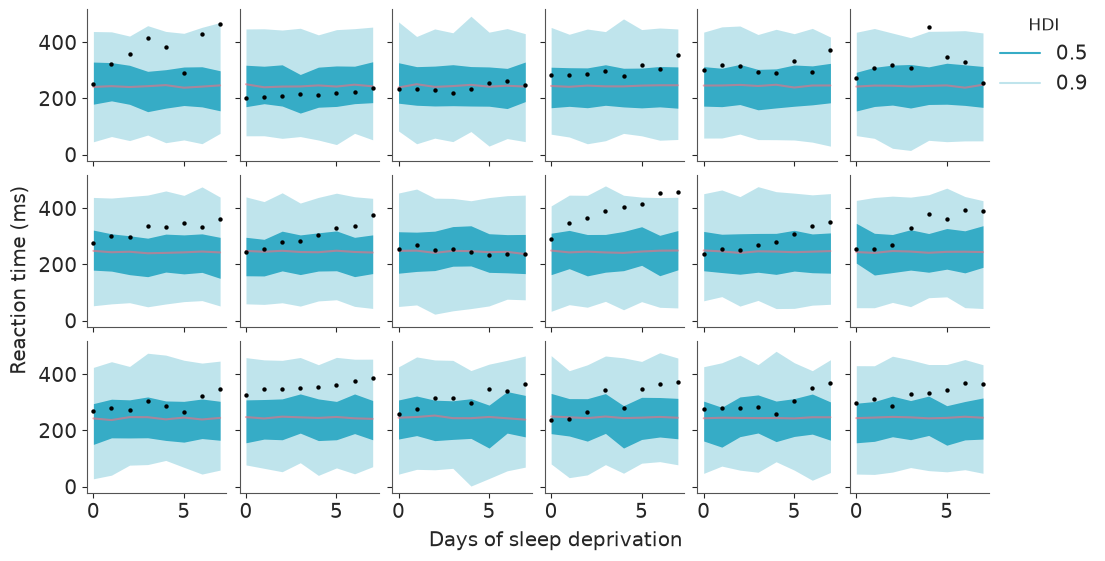

In [11]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.3 What criteria should we use for the prior predictive check?

What criteria did we establish in Notebook 1 for deciding whether prior predictive simulations are reasonable?

The same three criteria apply: physical possibility, plausible reaction times near baseline, and enough room for meaningful seven-day changes without routinely producing absurd trajectories.

The criteria from Notebook 1 were:

1. Predicted reaction times should not routinely be physically impossible.
2. Reaction times near the beginning of the experiment should mostly occupy a broadly plausible range.
3. The model should allow substantial changes over the seven days without routinely generating absurd trajectories.

The goal is broad plausibility, not reproducing the observed data before fitting.

### 2.4 Do the prior predictive simulations meet those criteria?

Apply the criteria from Question 2.3. In particular, does this prior allow a sufficiently broad range of changes over the seven days of sleep deprivation?

No. The main problem is the third criterion.

Because the prior constrains `b1` to be very close to zero, it makes substantial systematic changes across the seven days very unlikely. The prior predictive check therefore reveals that the model has been given an implausibly restrictive assumption about how much reaction time can change during the experiment.

## 3. Fit and diagnose — Can the model sample reliably?

### 3.1 Fit the model.

Use `pm.sample` to draw 1000 samples in each of 4 chains from the posterior distribution, with 1500 tuning samples.

In [12]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 17 seconds.


### 3.2 Calculate the numerical diagnostics.

Use `idata["sample_stats"]["diverging"].sum().item()` to count divergences and `azs.summary` to summarize `b0`, `b1`, and `sd_y` with a 90% HDI.

In [13]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,299.93,5.65,290.62,309.33,2476.06,2760.41,1.0,0.11,0.08
b1,2.29,0.91,0.75,3.73,2276.35,2523.92,1.0,0.02,0.01
sd_y,55.18,3.47,49.42,60.85,3370.58,2814.46,1.0,0.06,0.05


### 3.3 Plot the chain diagnostics.

Use `azp.plot_trace_dist` for `b0`, `b1`, and `sd_y`.

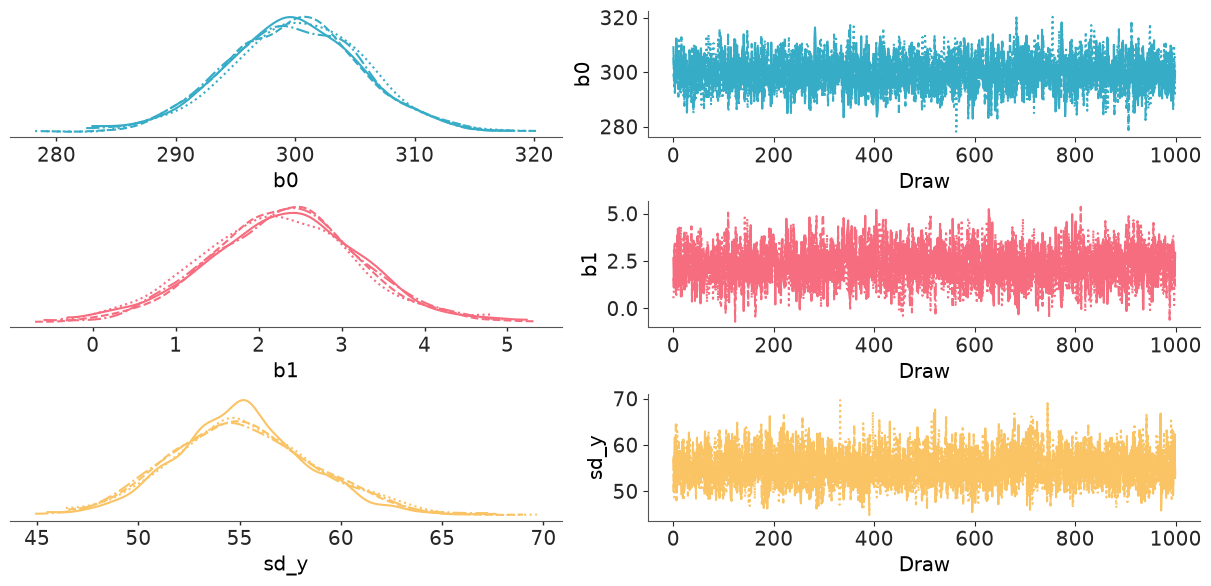

In [14]:
azp.plot_trace_dist(idata, var_names=["b0", "b1", "sd_y"]);

### 3.4 Did sampling succeed?

Do the numerical and graphical diagnostics meet the sampling criteria established in Notebook 1?

Yes. The chains mix well and the standard sampling diagnostics are satisfactory.

This is important: an inappropriate prior does not necessarily cause a sampling failure. We need the other parts of the workflow to evaluate the model itself.

## 4. Posterior predictive check — Does the fitted model reproduce the data?

### 4.1 Generate posterior predictive reaction times.

Use `pm.sample_posterior_predictive` to generate replicated values of `y` from the fitted model and add them to `idata`.

In [15]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [y]


Output()

### 4.2 Plot the posterior predictive reaction times.

Use the supplied `plot_participants` function to compare posterior predictive reaction times with the observed data for each participant.

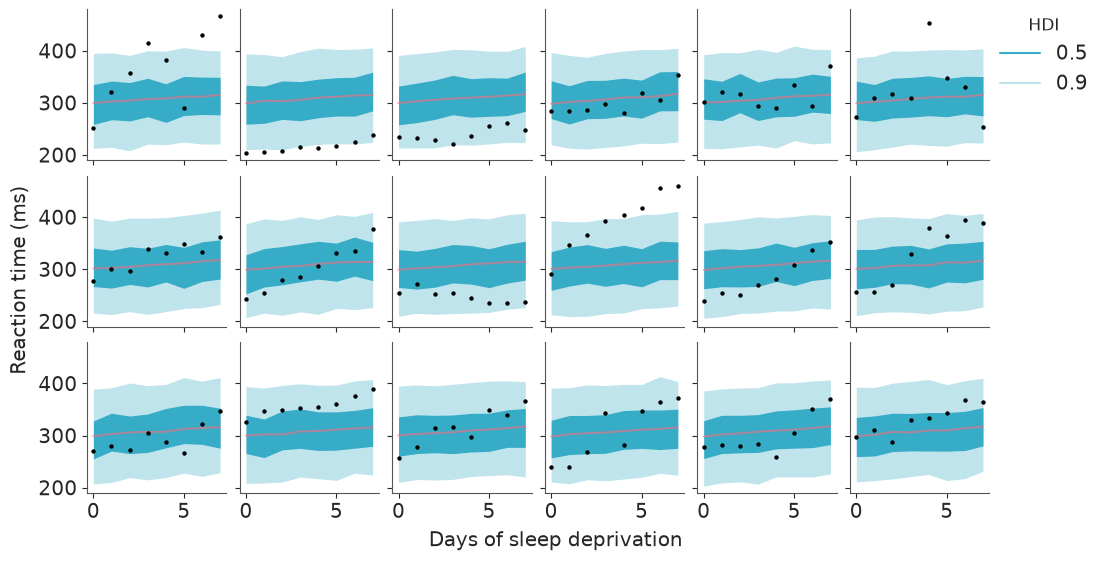

In [16]:
plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 4.3 What criteria should we use for the posterior predictive check?

What features did we use in Notebook 1 to decide whether posterior predictive simulations reproduce the important structure in the data?

We should compare participant levels, changes across days, and residual observation-to-observation variation, emphasizing systematic rather than isolated discrepancies.

We compare whether the replicated data reproduce:

1. participants' overall reaction-time levels;
2. changes in reaction time across days; and
3. observation-to-observation variation around those trends.

Systematic discrepancies that persist across observations are more important than isolated misses.

### 4.4 Does the fitted model reproduce the observed data?

Apply the criteria from Question 4.3. Pay particular attention to whether the fitted model reproduces the systematic increase in reaction time across days.

No. The posterior predictive distribution does not reproduce the systematic increase across days adequately.

The sampler has fitted the specified model successfully, but the fitted model still fails an important posterior predictive check.

## 5. Prior sensitivity — Does the posterior reveal prior-data conflict?

### 5.1 Why is prior sensitivity useful here?

A posterior predictive failure tells us that the fitted model does not reproduce an important feature of the data, but it does not by itself identify which assumption is responsible.

Power-scaling sensitivity asks how much the posterior changes when the prior or likelihood is given slightly more or slightly less weight. Because this notebook deliberately changed the slope prior, that provides a direct diagnostic of whether the prior is pulling against information in the data.

The next cell adds the log prior density and pointwise log likelihood required by ArviZ.

In [17]:
with model:
    pm.compute_log_likelihood(idata, model=model)
    compute_log_density(idata, model=model, kind="prior", extend_inferencedata=True)

Output()

Output()

### 5.2 Calculate power-scaling sensitivity.

Use `azs.psense_summary` for `b0`, `b1`, and `sd_y`.

In [18]:
azs.psense_summary(idata, var_names=["b0", "b1", "sd_y"])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
b0,0.191,0.212,potential prior-data conflict
b1,0.367,0.321,potential prior-data conflict
sd_y,0.074,0.175,potential prior-data conflict


### 5.3 Visualize the sensitivity.

Use `azp.plot_psense_dist` for `b0`, `b1`, and `sd_y`.

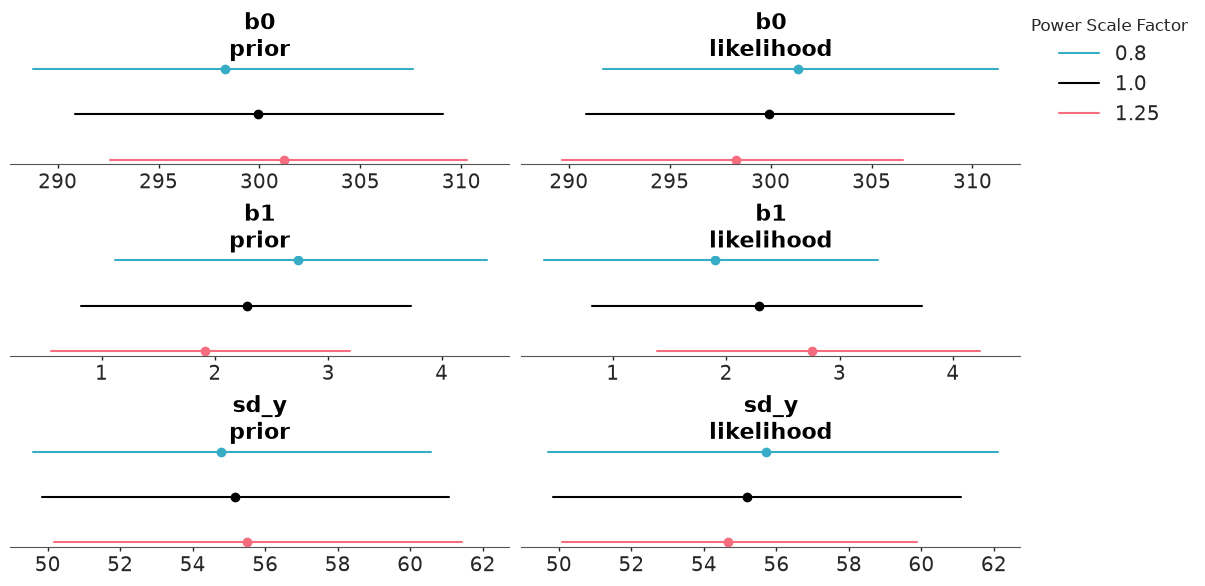

In [19]:
azp.plot_psense_dist(
    idata,
    var_names=["b0", "b1", "sd_y"],
    visuals={"dist": False},
);

### 5.4 Does the sensitivity analysis identify prior-data conflict?

ArviZ uses sensitivity values around 0.05 as a screening threshold. High sensitivity to both the prior and likelihood can indicate prior-data conflict.

Does the sensitivity analysis flag a problem?

Yes. The sensitivity diagnostics flag prior-data conflict.

This gives us a third indication, after the prior predictive and posterior predictive checks, that the restrictive slope prior is inappropriate for this analysis.